In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
master_df = pd.read_csv(
    "../data/processed/master_stock_data.csv"
)

# EDA SECTION 1 - DATA QUALITY CHECKS

In [3]:
master_df.head()

,Date,Close,High,Low,Open,Volume,Company
0,2019-01-01,496.196381,498.985034,491.371654,498.077624,9746670,Reliance
1,2019-01-02,489.733887,498.852220,487.343625,493.319235,15628818,Reliance
2,2019-01-03,483.691925,493.363540,482.518940,490.220816,16288287,Reliance
3,2019-01-04,486.303436,488.870748,478.535167,485.750155,18516544,Reliance
4,2019-01-07,489.003540,495.067675,487.343638,489.999475,12060290,Reliance


In [4]:
master_df.shape

(10374, 7)

In [5]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10374 entries, 0 to 10373
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     10374 non-null  object 
 1   Close    10374 non-null  float64
 2   High     10374 non-null  float64
 3   Low      10374 non-null  float64
 4   Open     10374 non-null  float64
 5   Volume   10374 non-null  int64  
 6   Company  10374 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 567.5+ KB


In [6]:
master_df['Date'] = pd.to_datetime(master_df['Date'])

In [7]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10374 entries, 0 to 10373
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     10374 non-null  datetime64[ns]
 1   Close    10374 non-null  float64       
 2   High     10374 non-null  float64       
 3   Low      10374 non-null  float64       
 4   Open     10374 non-null  float64       
 5   Volume   10374 non-null  int64         
 6   Company  10374 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 567.5+ KB


In [8]:
master_df.describe()

,Date,Close,High,Low,Open,Volume
count,10374,10374.000000,10374.000000,10374.000000,10374.000000,1.037400e+04
mean,2022-07-02 14:57:48.825910784,2101.489482,2124.057723,2079.390481,2102.435876,1.600355e+07
min,2019-01-01 00:00:00,104.390190,107.757598,95.422211,104.921878,0.000000e+00
25%,2020-10-05 00:00:00,458.669983,464.531512,450.880535,458.255881,5.895182e+06
50%,2022-06-30 00:00:00,786.568420,794.041744,779.840888,787.025818,1.137499e+07
75%,2024-04-02 00:00:00,1412.402466,1425.516488,1401.605621,1413.709052,1.994310e+07
max,2025-12-30 00:00:00,16703.000000,16818.000000,16558.000000,16709.000000,4.453421e+08
std,NaN,3248.310539,3281.457355,3215.080348,3249.315236,1.863358e+07


In [9]:
master_df.isnull().sum()

Date       0
Close      0
High       0
Low        0
Open       0
Volume     0
Company    0
dtype: int64

In [10]:
master_df.duplicated().sum()

np.int64(0)

# EDA SECTION 2 - DAILY RETURN ANALYSIS

In [11]:
master_df['Daily_Return'] = (
    master_df.groupby('Company')['Close']
    .pct_change()
)

In [12]:
master_df['Daily_Return']

0             NaN
1       -0.013024
2       -0.012337
3        0.005399
4        0.005552
           ...   
10369   -0.002463
10370   -0.003035
10371   -0.002735
10372   -0.001294
10373    0.008704
Name: Daily_Return, Length: 10374, dtype: float64

In [13]:
master_df.head()

,Date,Close,High,Low,Open,Volume,Company,Daily_Return
0,2019-01-01,496.196381,498.985034,491.371654,498.077624,9746670,Reliance,NaN
1,2019-01-02,489.733887,498.852220,487.343625,493.319235,15628818,Reliance,-0.013024
2,2019-01-03,483.691925,493.363540,482.518940,490.220816,16288287,Reliance,-0.012337
3,2019-01-04,486.303436,488.870748,478.535167,485.750155,18516544,Reliance,0.005399
4,2019-01-07,489.003540,495.067675,487.343638,489.999475,12060290,Reliance,0.005552


In [14]:
master_df.dropna(inplace=True)

In [15]:
master_df.shape

(10368, 8)

In [16]:
master_df['Company'].value_counts()

Company
Reliance     1728
Infosys      1728
HDFC_Bank    1728
ITC          1728
Maruti       1728
SBI          1728
Name: count, dtype: int64

In [17]:
master_df['Date'].min()

Timestamp('2019-01-02 00:00:00')

In [18]:
master_df['Date'].max()

Timestamp('2025-12-30 00:00:00')

In [19]:
master_df.groupby('Company')['Close'].agg(
    ['min','max','mean']
)

,min,max,mean
Company,,,
HDFC_Bank,363.573395,1012.900024,716.237201
ITC,104.390190,463.949249,269.579527
Infosys,442.779846,1901.083008,1217.262699
Maruti,3810.497070,16703.000000,8851.726853
Reliance,393.662384,1581.824463,1064.194765
SBI,136.727295,966.479187,492.015769


# EDA SECTION 3 - PRICE TREND ANALYSIS

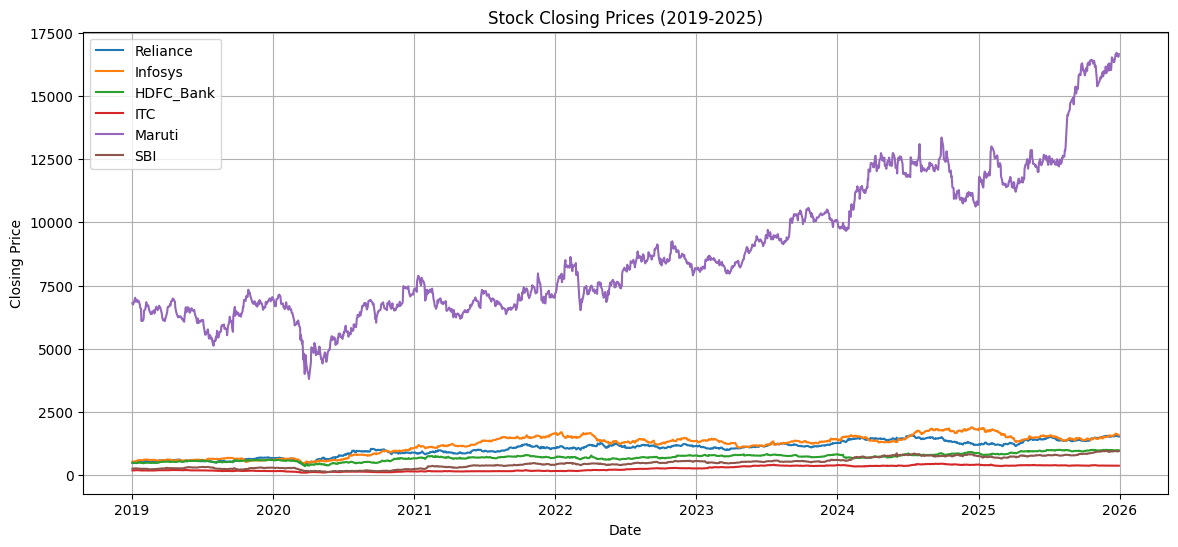

In [20]:
plt.figure(figsize=(14,6))

for company in master_df['Company'].unique():

    company_data = master_df[
        master_df['Company'] == company
    ]

    plt.plot(
        company_data['Date'],
        company_data['Close'],
        label=company
    )

plt.title('Stock Closing Prices (2019-2025)')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.grid(True)

plt.show()

# EDA SECTION 4 - NORMALIZED STOCK PRICES

What is happening?

Suppose:

Day	Close
Day 1	500
Day 2	550

Then:

Day 1 = 100
Day 2 = 110

Meaning:

Stock grew 10% from the starting point.

In [21]:
normalized_df = master_df.copy()

normalized_df['Normalized_Close'] = (
    normalized_df.groupby('Company')['Close']
    .transform(lambda x: x / x.iloc[0] * 100)
)

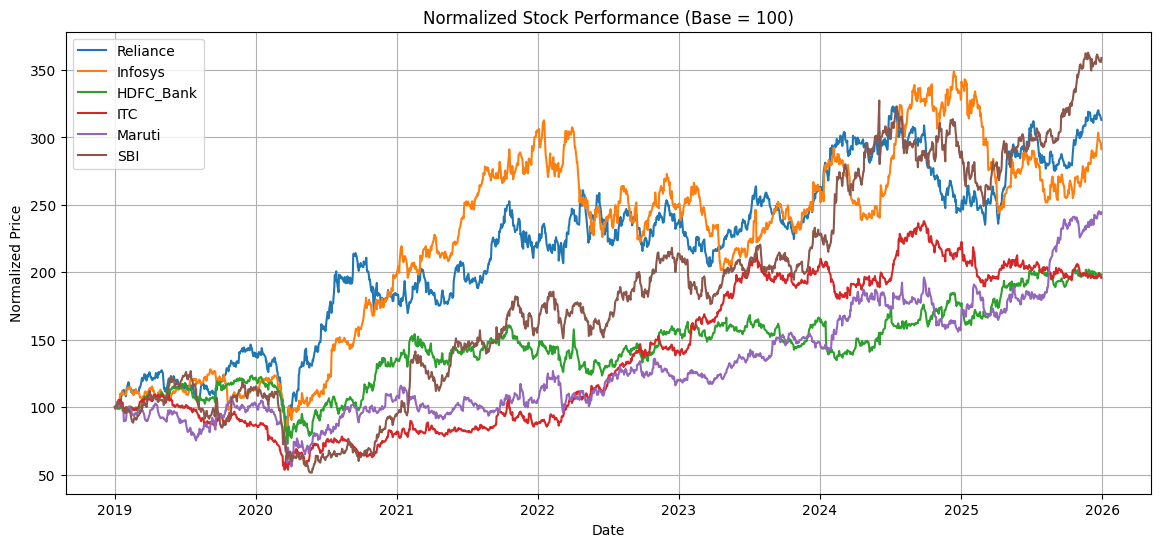

In [22]:
plt.figure(figsize=(14,6))

for company in normalized_df['Company'].unique():

    company_data = normalized_df[
        normalized_df['Company'] == company
    ]

    plt.plot(
        company_data['Date'],
        company_data['Normalized_Close'],
        label=company
    )

plt.title('Normalized Stock Performance (Base = 100)')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend()
plt.grid(True)

plt.show()

| Stock     | Approx End Value | Interpretation     |
| --------- | ---------------- | ------------------ |
| SBI       | ~360             | Best performer     |
| Reliance  | ~320             | Strong performer   |
| Infosys   | ~300             | Strong performer   |
| Maruti    | ~240             | Moderate performer |
| ITC       | ~200             | Stable performer   |
| HDFC Bank | ~200             | Stable performer   |


Meaning:

SBI gave roughly 260% return
Reliance gave roughly 220% return
Infosys gave roughly 200% return
ITC and HDFC Bank roughly doubled

Also notice:

COVID Crash (2020)

All stocks fell sharply.

This is useful because:

A stock that falls more during market crashes is usually riskier.

Which leads directly to our next EDA topic:

# EDA Section 5 — Daily Return Distribution Analysis.

now we want to understand:

Are returns usually small or large?
Are there extreme losses?
Are there extreme gains?
Is the stock risky?

In [23]:
master_df['Daily_Return'].describe()

count    10368.000000
mean         0.000698
std          0.017387
min         -0.169092
25%         -0.007706
50%          0.000406
75%          0.008752
max          0.147180
Name: Daily_Return, dtype: float64

Mean = 0.000698
Std  = 0.017387
Min  = -0.169092
Max  = 0.147180

Average daily return ≈ 0.0698%
per day

The stock basket moves roughly ±1.74% on a normal day.

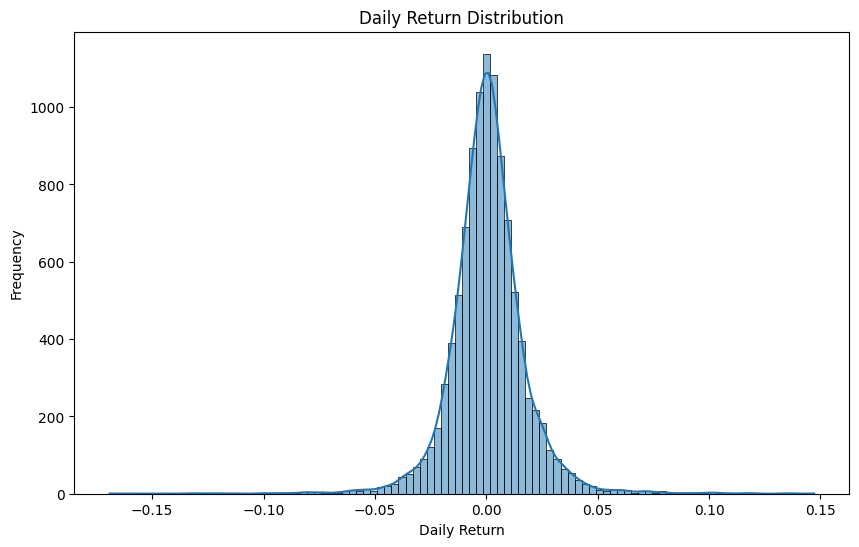

In [24]:
plt.figure(figsize=(10,6))

sns.histplot(
    master_df['Daily_Return'],
    bins=100,
    kde=True
)

plt.title('Daily Return Distribution')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')

plt.show()

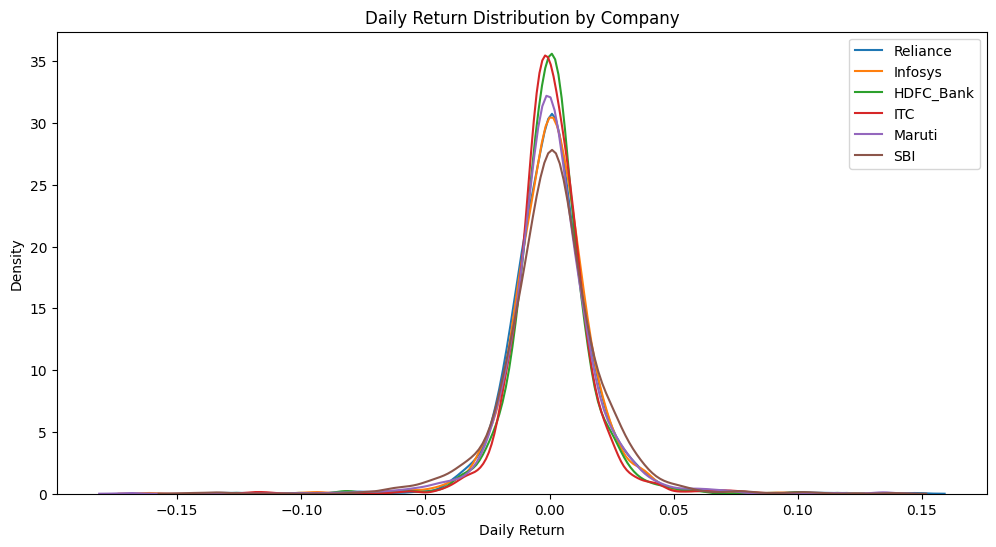

In [25]:
plt.figure(figsize=(12,6))

for company in master_df['Company'].unique():

    sns.kdeplot(
        master_df[
            master_df['Company'] == company
        ]['Daily_Return'],
        label=company
    )

plt.title('Daily Return Distribution by Company')
plt.xlabel('Daily Return')
plt.legend()

plt.show()

Notice:

HDFC Bank curve is taller and narrower

SBI curve is wider

Infosys and Reliance are in between

Rule:

Taller curve=Less volatility=Lower risk

Wider curve=More volatility=Higher risk

Visually it appears:

Lowest Risk
↓
HDFC Bank
ITC
Reliance
Infosys
Maruti
SBI
↑
Highest Risk

# EDA 6-Volatility Analysis

In [26]:
volatility = (
    master_df.groupby('Company')['Daily_Return']
    .std()
    .sort_values(ascending=False)
)

volatility

Company
SBI          0.019882
Maruti       0.018247
Reliance     0.017698
Infosys      0.017305
HDFC_Bank    0.015700
ITC          0.015073
Name: Daily_Return, dtype: float64

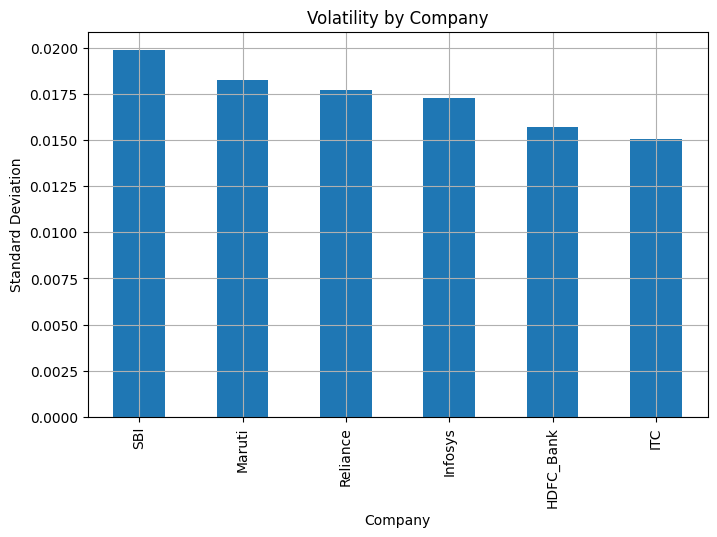

In [27]:
plt.figure(figsize=(8,5))

volatility.plot(
    kind='bar'
)

plt.title('Volatility by Company')
plt.ylabel('Standard Deviation')
plt.grid(True)

plt.show()

| Company   | Volatility |
| --------- | ---------- |
| SBI       | 0.019852   |
| Maruti    | 0.018247   |
| Reliance  | 0.017608   |
| Infosys   | 0.017105   |
| HDFC Bank | 0.015700   |
| ITC       | 0.015073   |


Think of volatility as:
How violently the stock price moves daily

Higher volatility = Higher Risk

Lower volatility = Lower Risk

SBI = Riskiest with
Volatility = 1.985%

Very sensitive to:

Interest rates
Banking news
Market sentiment

Maruti = Second Riskiest
Volatility = 1.825%

Affected by:

Auto sales
Fuel prices
Consumer demand

Reliance
Volatility = 1.761%

Moderately risky.

Infosys
Volatility = 1.711%

Affected by:

US economy
Dollar movement
IT spending

HDFC Bank
Volatility = 1.57%

Relatively stable.

ITC = Safest
Volatility = 1.507%

Most defensive stock in your portfolio.

Investors buy ITC during uncertainty.

# EDA 6-Correlation Analysis¶

In [28]:
close_prices = master_df.pivot(
    index='Date',
    columns='Company',
    values='Close'
)

close_prices.head()

Company,HDFC_Bank,ITC,Infosys,Maruti,Reliance,SBI
Date,,,,,,
2019-01-02,499.790222,195.043030,544.984131,6808.712402,489.733887,266.384796
2019-01-03,495.868927,193.826599,545.065552,6748.849609,483.691925,263.846954
2019-01-04,497.195648,195.286285,538.467590,6777.469238,486.303436,269.783722
2019-01-07,497.946960,195.772858,547.142639,6896.960938,489.003540,268.560120
2019-01-08,493.802612,197.580093,545.798584,6969.518066,488.959259,276.717529


In [29]:
correlation_matrix = close_prices.corr()

correlation_matrix

Company,HDFC_Bank,ITC,Infosys,Maruti,Reliance,SBI
Company,,,,,,
HDFC_Bank,1.000000,0.785582,0.801538,0.850219,0.831849,0.893125
ITC,0.785582,1.000000,0.662233,0.868371,0.784297,0.906533
Infosys,0.801538,0.662233,1.000000,0.675335,0.874682,0.792477
Maruti,0.850219,0.868371,0.675335,1.000000,0.836281,0.943047
Reliance,0.831849,0.784297,0.874682,0.836281,1.000000,0.879887
SBI,0.893125,0.906533,0.792477,0.943047,0.879887,1.000000


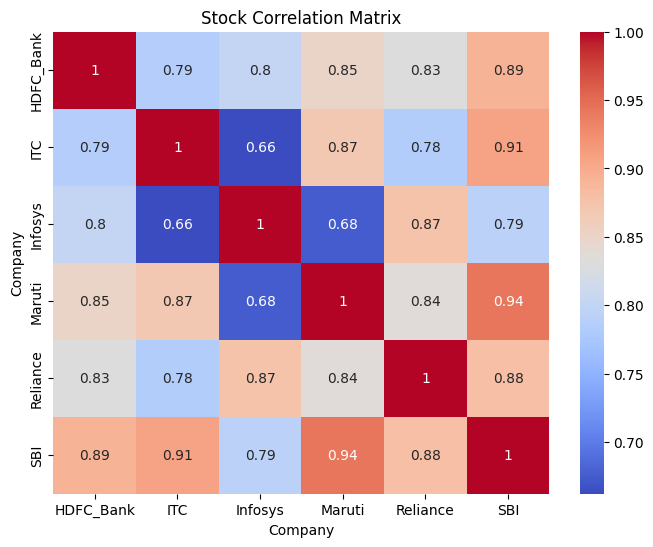

In [30]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Stock Correlation Matrix')

plt.show()

Correlation analysis revealed that SBI and Maruti exhibited the strongest relationship (0.94), indicating similar market behavior. Infosys and ITC showed the lowest correlation (0.66), making them a better diversification pair for portfolio construction.

# EDA Section 7 - Rolling Volatility Analysis

Current volatility gives:

SBI = 0.0198

But that's the average risk from 2019-2025.

We want:

How risky was SBI in 2020?
How risky was SBI in 2022?
How risky is SBI now?

That's Rolling Volatility.

Step 1 — Create 30-Day Rolling Volatility

In [31]:
rolling_volatility = master_df.copy()

rolling_volatility['Rolling_Volatility'] = (
    rolling_volatility
    .groupby('Company')['Daily_Return']
    .rolling(window=30)
    .std()
    .reset_index(level=0, drop=True)
)

rolling_volatility.head()

,Date,Close,High,Low,Open,Volume,Company,Daily_Return,Rolling_Volatility
1,2019-01-02,489.733887,498.852220,487.343625,493.319235,15628818,Reliance,-0.013024,NaN
2,2019-01-03,483.691925,493.363540,482.518940,490.220816,16288287,Reliance,-0.012337,NaN
3,2019-01-04,486.303436,488.870748,478.535167,485.750155,18516544,Reliance,0.005399,NaN
4,2019-01-07,489.003540,495.067675,487.343638,489.999475,12060290,Reliance,0.005552,NaN
5,2019-01-08,488.959259,491.305229,485.130438,489.158440,12304389,Reliance,-0.000091,NaN


In [32]:
rolling_volatility[
    ['Date','Company','Rolling_Volatility']
].head(40)

,Date,Company,Rolling_Volatility
1,2019-01-02,Reliance,NaN
2,2019-01-03,Reliance,NaN
3,2019-01-04,Reliance,NaN
4,2019-01-07,Reliance,NaN
5,2019-01-08,Reliance,NaN
6,2019-01-09,Reliance,NaN
7,2019-01-10,Reliance,NaN
8,2019-01-11,Reliance,NaN
9,2019-01-14,Reliance,NaN
10,2019-01-15,Reliance,NaN


In [33]:
rolling_volatility.dropna(
    subset=['Rolling_Volatility'],
    inplace=True
)

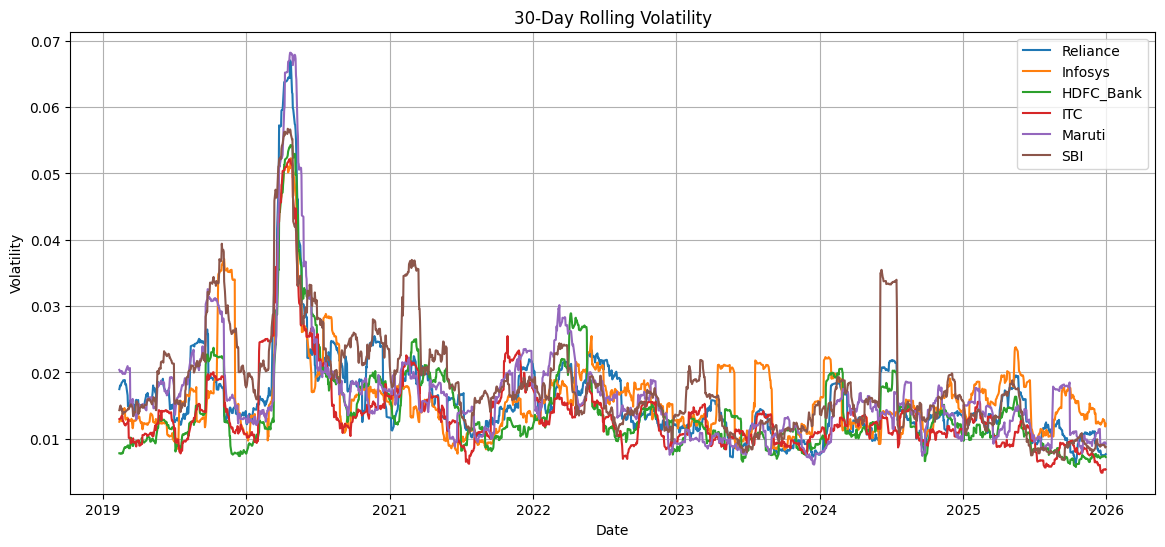

In [34]:
plt.figure(figsize=(14,6))

for company in rolling_volatility['Company'].unique():

    company_data = rolling_volatility[
        rolling_volatility['Company'] == company
    ]

    plt.plot(
        company_data['Date'],
        company_data['Rolling_Volatility'],
        label=company
    )

plt.title('30-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)

plt.show()

1. Massive Volatility Spike in 2020

Look at the huge jump around:

March-April 2020

All stocks suddenly spike.

Reason:

👉 COVID-19 market crash

Markets worldwide fell sharply and uncertainty exploded.

You can clearly see volatility reaching:

~0.05 to 0.07

which is 3–5 times normal levels.

2. Maruti Became Most Volatile During COVID

Purple line:

Maruti

peaks around:

0.068

Highest among all stocks.

Interpretation

Auto sector was heavily affected by:

Lockdowns
Supply chain disruption
Lower consumer spending
3. SBI Shows Repeated Risk Spikes

Brown line:

SBI

has multiple large spikes:

2020
2021
2024

This confirms what volatility ranking showed earlier:

SBI = Highest Risk Stock
4. ITC Remains Relatively Stable

Red line:

ITC

shows smaller movements.

This supports your previous finding:

ITC = Lowest Volatility
5. Market Stabilizes After 2022

After:

2022

most lines remain between:

0.008 – 0.02

Meaning:

Lower uncertainty
More stable market conditions

Rolling volatility analysis highlighted significant risk spikes during the COVID-19 market crash in 2020. Maruti experienced the highest volatility, while ITC remained comparatively stable throughout the study period. SBI consistently exhibited higher volatility than other stocks, indicating greater risk exposure.

# Section 7 — Risk vs Return Analysis

For each stock:

Return

Average Daily Return

=mean(Daily_Return)



Risk

Volatility

=std(Daily_Return)

In [35]:
risk_return = master_df.groupby('Company')['Daily_Return'].agg(
    ['mean', 'std']
)

risk_return.columns = [
    'Average_Return',
    'Risk'
]

risk_return

,Average_Return,Risk
Company,,
HDFC_Bank,0.000514,0.015700
ITC,0.000499,0.015073
Infosys,0.000773,0.017305
Maruti,0.000667,0.018247
Reliance,0.000809,0.017698
SBI,0.000927,0.019882


Suppose Reliance returns:

+1%
-2%
+3%
+1%

Average Return:

(1 -2 +3 +1)/4
= 0.75%

Risk:

How far values move from average

Large movement:

+10%
-8%
+15%

↓

High Risk

Small movement:

+1%
+2%
+1%

↓

Low Risk

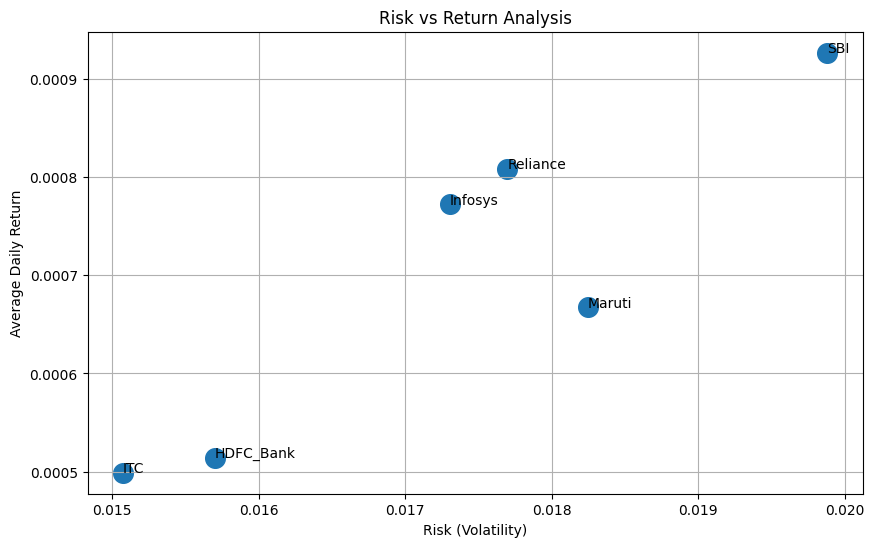

In [36]:
plt.figure(figsize=(10,6))

plt.scatter(
    risk_return['Risk'],
    risk_return['Average_Return'],
    s=200
)

for company in risk_return.index:

    plt.annotate(
        company,
        (
            risk_return.loc[company, 'Risk'],
            risk_return.loc[company, 'Average_Return']
        )
    )

plt.title('Risk vs Return Analysis')
plt.xlabel('Risk (Volatility)')
plt.ylabel('Average Daily Return')

plt.grid(True)

plt.show()


Highest risk

Investor type:

Aggressive investor
Higher risk tolerance
🥈 Reliance — Best Risk-Adjusted Stock
Metric	Value
Return	0.000809
Risk	0.017698

Reliance gives:

Very high return
Moderate risk

Compared to SBI:

SBI:
+ little more return
+ much more risk

Reliance:
high return
lower risk

This is why Reliance is arguably the strongest stock in your dataset.

🥉 Infosys — Efficient Growth Stock
Metric	Value
Return	0.000773
Risk	0.017305

Infosys provides:

Good returns
Lower risk than SBI and Maruti

Very attractive risk-return balance.

Maruti
Metric	Value
Return	0.000667
Risk	0.018247

Compared with Reliance:

Higher risk
Lower return

Not very efficient.

HDFC Bank
Metric	Value
Return	0.000514
Risk	0.015700

Defensive stock.

Lower return but safer.

ITC
Metric	Value
Return	0.000499
Risk	0.015073

Safest stock.

Good for:

Capital preservation
Stable investing
Final Ranking
Return Ranking
1. SBI
2. Reliance
3. Infosys
4. Maruti
5. HDFC Bank
6. ITC

Risk Ranking
1. SBI
2. Maruti
3. Reliance
4. Infosys
5. HDFC Bank
6. ITC

SBI generated the highest average daily return but also exhibited the highest volatility, making it the riskiest stock.

ITC demonstrated the lowest volatility and most stable performance among all stocks.

Reliance offered one of the best risk-return tradeoffs, combining strong returns with moderate risk.

Correlation analysis revealed that SBI and Maruti were highly correlated (0.94), while Infosys and ITC showed the lowest correlation (0.66), providing diversification benefits.

Rolling volatility analysis highlighted significant market-wide risk spikes during the COVID-19 crash in 2020.

Normalized performance analysis showed that SBI and Reliance delivered the strongest long-term growth over the study period.